In questo notebook esploriamo il concetto di attention, che è alla base dei sistemi di oggi (incluso GPT-4).

Iniziamo col semplice esempio della query sul prezzo delle bibite a un database. Query, keys, e values sono rappresentati con vettori di embeddings 2D con valori scelti arbitrariamente, ma in modo che il vettore della query sia molto vicino alle keys delle bibite e molto lontano dalla key del panino.

In [1]:
import numpy as np

# La query è rappresentata da un vettore di embedding
# Le keys sono rappresentate da vettori di embedding (uno per key)

query = np.array([-15, 15])  

# L'idea è che il vettore della query assomiglia ai vettori delle keys interessate dalla query ma non alle keys estranee alla query
keys = {
    'panino': np.array([10, -10]),
    'acqua': np.array([-16, 14]),
    'birra': np.array([-12, 18])
}
values = np.array([5, 1, 3])

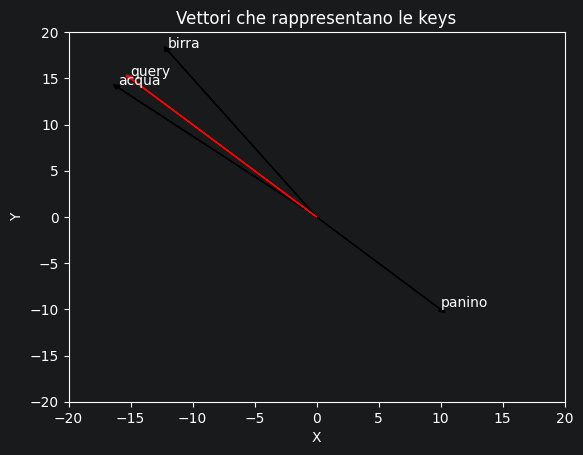

In [2]:
import matplotlib.pyplot as plt
import numpy as np



fig, ax = plt.subplots()


for key in keys.keys():
    ax.arrow(0, 0, keys[key][0], keys[key][1], head_width=0.5, head_length=0.5, fc='black', ec='black')
    ax.text(keys[key][0], keys[key][1], key, ha='left', va='bottom')


ax.set_xlim([-20, 20])
ax.set_ylim([-20, 20])

ax.arrow(0, 0, query[0], query[1], head_width=0.5, head_length=0.5, fc='red', ec='red')
ax.text(query[0], query[1], 'query', ha='left', va='bottom')


ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Vettori che rappresentano le keys')


plt.show()



Adesso calcoliamo il prezzo medio delle bibite con una forma base di attention, che fa tre cose:


*   prodotto scalare tra query vector e key vectors, ottenendo un vettore dei valori dei singoli prodotti scalari con i singoli key vectors 
*   normalizzazione softmax per ottenere un vettore di pesi che sommino a uno (quindi interpretabile come una distribuzione di probabilità sui values)
*   prodotto scalare tra vettore di valori normalizzati e value vector, che in pratica fa da media ponderata dei valori nel value vector usando i coefficienti di normalizzazione come pesi, e quindi da il prezzo medio delle bibite




In [3]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()



similarity_scores = np.array([np.dot(query, key) for key in keys.values()])
print ('vettore coi risultati del prodotto scalare tra query vector e key vectors', similarity_scores)

normalized_scores = softmax(similarity_scores)
print ('normalizzazione softmax', normalized_scores)

weighted_average = np.dot(normalized_scores, values)
print("prodotto scalare tra vettore di valori normalizzati e value vector", weighted_average)


vettore coi risultati del prodotto scalare tra query vector e key vectors [-300  450  450]
normalizzazione softmax [0.  0.5 0.5]
prodotto scalare tra vettore di valori normalizzati e value vector 2.0


Nei modelli del linguaggio in uso oggi si usa una versione leggermente modificata che scala i valori del prodotto scalare tra query e keys in base al numero di dimensioni dei vettori, perché al crescere delle dimensioni il prodtto scalare tra query e keys tende a essere

In [4]:
import numpy as np

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def scaled_dot_product_attention(query, keys, values):

    query = np.array(query, dtype=np.float64)
 
    similarity_scores = np.array([np.dot(query, key) for key in keys])

    print ('vettore coi risultati del prodotto scalare tra query vector e key vectors', similarity_scores)

    
    scaling_factor = np.sqrt(keys.shape[-1])
    scaled_similarity_scores = similarity_scores / scaling_factor

    print ('versione scalata', scaled_similarity_scores)

    normalized_scores = softmax(scaled_similarity_scores)

    print ('normalizzazione softmax', normalized_scores)

    weighted_sum = np.dot(normalized_scores, values)

    print("prodotto scalare tra vettore di valori normalizzati e value vector", weighted_average)

    return weighted_sum



dict_to_array = lambda keys_dict: np.array([v for v in keys_dict.values()], dtype=np.float64)

keys_array = dict_to_array(keys)

output = scaled_dot_product_attention(query, keys_array, values)
print(output)


vettore coi risultati del prodotto scalare tra query vector e key vectors [-300.  450.  450.]
versione scalata [-212.13203436  318.19805153  318.19805153]
normalizzazione softmax [2.39629408e-231 5.00000000e-001 5.00000000e-001]
prodotto scalare tra vettore di valori normalizzati e value vector 2.0
2.0


Segue l'esempio delle slides sulla moltiplicazione per una matrice come proiezione in un nuovo spazio vettoriale.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


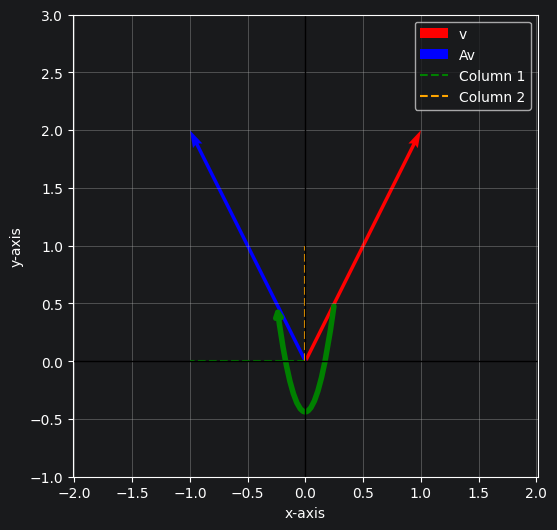

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch


v = np.array([1, 2])


A = np.array([[-1, 0],
              [0, 1]])


w = np.dot(A, v)


plt.figure(figsize=(6, 6))


def curved_arrow(ax, start, end, radius=2.5, color='black', lw=1):
    arrow = FancyArrowPatch(start, end, connectionstyle=f"arc3,rad={radius}",
                            arrowstyle='->', mutation_scale=10, lw=lw, color=color)
    ax.add_patch(arrow)


plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='r', label='v')
plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='b', label='Av')
plt.plot([0, A[0, 0]], [0, A[1, 0]], 'g--', label='Column 1')
plt.plot([0, A[0, 1]], [0, A[1, 1]], 'orange', linestyle='dashed', label='Column 2')


curved_arrow(plt.gca(), v * 0.25, w * 0.25, radius=-3.7, color='green', lw=4)
plt.axis('equal')

plt.xlim(-3, 3)
plt.ylim(-1, 3)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)


plt.xlabel('x-axis')
plt.ylabel('y-axis')
plt.legend()
plt.grid()


plt.show()


Adesso vediamo come usare il meccanismo di attention per rispondere a domande le cui risposte si trovano in un database (simulato da un dict). Notate che le domande (queries) non contengono necessariamente tutte le keywords (keys).

In [6]:
! pip install sentence-transformers

  Using cached pyyaml-6.0.3-cp313-cp313-win_amd64.whl.metadata (2.4 kB)
  Using cached regex-2026.4.4-cp313-cp313-win_amd64.whl.metadata (41 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
   ---------------------------------------- 0.0/571.3 kB ? eta -:--:--
   --------------------------------------- 571.3/571.3 kB 15.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/10.2 MB ? eta -:--:--
   ---------------------------------------- 10.2/10.2 MB 49.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/645.5 kB ? eta -:--:--
   --------------------------------------- 645.5/645.5 kB 23.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.7 MB ? eta -:--:--
   ---------------------------------------- 3.7/3.7 MB 47.1 MB/s eta 0:00:00
Using c

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_embeddings(embeddings, labels, title):
    # Reduce the dimensionality to 2D
    pca = PCA(n_components=2)
    embeddings_2d = pca.fit_transform(embeddings)

    # Create a scatter plot
    plt.figure()
    for i, label in enumerate(labels):
        if label == "Query":
            plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], c='red', marker='o', label='Query')
        elif label == "Attended Value":
            plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], c='red', marker='x', linewidth=2, label='Attended Value')
        else:
            plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], c='blue', marker='.')

    # Add labels to each point
    for i, label in enumerate(labels):
        if label == "Attended Value":
            # Add a small offset to the "Attended Value" label
            offset = 0.05 * np.array([1, 1])
            plt.annotate(label, (embeddings_2d[i, 0] + offset[0], embeddings_2d[i, 1] + offset[1]))
        elif label != "Query":
            plt.annotate(label, (embeddings_2d[i, 0], embeddings_2d[i, 1]))

    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title(title)
    plt.legend()
    plt.show()


In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('distiluse-base-multilingual-cased-v2')


from sklearn.metrics.pairwise import cosine_similarity
from scipy.special import softmax


def get_answer (query, keys, values, model, visualize = True):

    key_embeddings = model.encode(keys)
    value_embeddings = model.encode(values)
    query_embedding = model.encode(query)


    attention_scores = np.dot(query_embedding, key_embeddings.T)
    attention_weights = softmax(attention_scores)
    attended_value = np.dot(attention_weights, value_embeddings)


    similarities = cosine_similarity([attended_value], value_embeddings)
    max_sim_index = np.argmax(similarities)

    final_answer = values[max_sim_index]

    if visualize:
        all_embeddings = np.vstack([key_embeddings, value_embeddings, query_embedding[np.newaxis, :], attended_value[np.newaxis, :]])
        all_labels = keys + values + ['Query'] + ['Attended Value']
        plot_embeddings(all_embeddings, all_labels, 'Embeddings proiettati in 2D')

    return final_answer




ModuleNotFoundError: No module named 'sentence_transformers'

In [ ]:
keys = [
    "capitale Svizzera",
    "montagna più alta Ticino",
    "lingua Lugano",
    "traffico venerdì",
    "colore preferito",
]

values = [
    "Berna",
    "Adula",
    "Italiano",
    "congestionato",
    "giallo",
]

query = "Qual è la capitale della Svizzera?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
query = "Che lingua parlano a Lugano?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
query = "Qual è il monte più alto del Ticino?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
query = "Oggi è venerdì; com'è il traffico?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
query = "Hai un colore che ti piace particolarmente?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Initialize the Sentence Transformer model
model = SentenceTransformer('paraphrase-distilroberta-base-v2')

# Define the toy database
keys = [
    "capital of Switzerland",
    "largest city of Switzerland",
    "official language in Lugano",
    "top tennis tournament in Switzerland",
]

values = [
    "Bern",
    "Zurich",
    "Italian",
    "Basel",
]

query = "What language do they speak in Lugano?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
query = "What tournament should I attend here in Switzerland?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')

keys = [
    "capitale Svizzera",
    "montagna più alta Ticino",
    "lingua Lugano",
    "traffico venerdì",
    "colore preferito",
    "piatto tipico Ticino",
    "fiume principale Berna",
    "valuta Svizzera",
    "autore famoso Svizzera",
    "pittore celebre Svizzera",
]

values = [
    "Berna",
    "Adula",
    "Italiano",
    "congestionato",
    "giallo",
    "polenta",
    "Aar",
    "franco svizzero",
    "Hermann Hesse",
    "Paul Klee",
]
query = "Qual è la valuta usata in Svizzera?"
final_answer= get_answer (query, keys, values, model)
print (final_answer)

In [ ]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import precision_score, recall_score
from scipy.special import softmax

keys = [
    "capitale Svizzera",
    "monte più alto Ticino",
    "lingua Lugano",
    "traffico venerdì",
    "colore preferito",
    "piatto tipico Ticino",
    "fiume principale Berna",
    "valuta Svizzera",
    "scrittore famoso Svizzera",
    "pittore celebre Svizzera",
    "protagonista barzellette",
    "cantone confinante Ticino nord",
    "cantone confinante Ticino est",
    "cantone confinante Ticino ovest",
]

values = [
    "Berna",
    "Adula",
    "Italiano",
    "congestionato",
    "giallo",
    "polenta",
    "Aare",
    "franco svizzero",
    "Hermann Hesse",
    "Paul Klee",
    "Pierino",
    "Uri",
    "Grigioni",
    "Vallese",
]

dataset = [
    {
        "question": "Qual è la capitale della Svizzera?",
        "keys": keys,
        "ground_truth": "Berna",
    },
    {
        "question": "Qual è la montagna più alta del Ticino?",
        "keys": keys,
        "ground_truth": "Adula",
    },
    {
        "question": "Che si parla a Lugano?",
        "keys": keys,
        "ground_truth": "Italiano",
    },
    {
        "question": "Com'è' il traffico oggi, che è venerdì?",
        "keys": keys,
        "ground_truth": "congestionato",
    },
    {
        "question": "Qual è il tuo colore preferito?",
        "keys": keys,
        "ground_truth": "giallo",
    },
    {
        "question": "Conosci un esempio di un piatto tipico del Ticino?",
        "keys": keys,
        "ground_truth": "polenta",
    },
    {
        "question": "Qual è il fiume che passa da Berna?",
        "keys": keys,
        "ground_truth": "Aare",
    },
    {
        "question": "Qual è la valuta usata in Svizzera?",
        "keys": keys,
        "ground_truth": "franco svizzero",
    },
    {
        "question": "Chi è uno scrittore tedesco famoso che ha vissuto in Svizzera?",
        "keys": keys,
        "ground_truth": "Hermann Hesse",
    },
    {
        "question": "Chi è un pittore celebre della Svizzera?",
        "keys": keys,
        "ground_truth": "Paul Klee",
    },
    {
        "question": "Chi è un famoso personaggio delle barzellette?",
        "keys": keys,
        "ground_truth": "Pierino",
    },
    {
        "question": "Con quale cantone confina il Ticino a ovest?",
        "keys": keys,
        "ground_truth": "Vallese",
    },
        {
        "question": "Con quale cantone confina il Ticino a est?",
        "keys": keys,
        "ground_truth": "Grigioni",
    },
            {
        "question": "Con quale cantone confina il Ticino a nord?",
        "keys": keys,
        "ground_truth": "Uri",
    },
]


key_embeddings = model.encode(keys)
value_embeddings = model.encode(values)

def dot_product_attention(query, key, value):
    scores = np.dot(query, key.T)
    attention_weights = softmax(scores)
    attended_value = np.dot(attention_weights, value)

    return attended_value, attention_weights

def predict_answer(question, keys, key_embeddings, value_embeddings):
    query_embedding = model.encode(question)
    attended_value, attention_weights = dot_product_attention(
        query_embedding, key_embeddings, value_embeddings
    )
    similarities = cosine_similarity([attended_value], value_embeddings)
    max_sim_index = np.argmax(similarities)
    
    return values[max_sim_index]



def evaluate_performance(dataset, key_embeddings, value_embeddings):
    ground_truths = [item["ground_truth"] for item in dataset]
    predictions = [
        predict_answer(item["question"], item["keys"], key_embeddings, value_embeddings)
        for item in dataset
    ]

    incorrect_questions = []

    for i, (ground_truth, prediction) in enumerate(zip(ground_truths, predictions)):
        if ground_truth != prediction:
            incorrect_questions.append((dataset[i]["question"], ground_truth, prediction))

    print("Incorrectly answered questions:")
    for question, ground_truth, prediction in incorrect_questions:
        print(f"Question: {question}")
        print(f"Ground Truth: {ground_truth}")
        print(f"Prediction: {prediction}")
        print()


    accuracy = accuracy_score(ground_truths, predictions)
    precision = precision_score(ground_truths, predictions, average="weighted", zero_division=0)
    recall = recall_score(ground_truths, predictions, average="weighted", zero_division=0)

    

    f1 = f1_score(ground_truths, predictions, average="weighted")

    return {"accuracy": accuracy, "f1_score": f1, "precision": precision, "recall": recall, "f1_score": f1}

metrics = evaluate_performance(dataset, key_embeddings, value_embeddings)
print("Evaluation Metrics:")
print("Accuracy:", metrics["accuracy"])
print("F1 Score:", metrics["f1_score"])
print("Precision:", metrics["precision"])
print("Recall:", metrics["recall"])


Segue l'esempio delle slides *una pesca dolce*

In [ ]:
import numpy as np
from scipy.special import softmax


matrix = np.array([
    [0.04, 0.48, 0.48],
    [0.09, 0.01, 0.90],
    [0.11, 0.88, 0.01]
])


v_una = np.array([1, 0])
v_pesca = np.array([2, 4])
v_dolce = np.array([-2, 6])


V = np.column_stack((v_una, v_pesca, v_dolce)).T


result = np.matmul(matrix, V)

print("Matrix * V =\n", result)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


V = np.array([
    [1, 0],
    [2, 4],
    [-2, 6]
])



fig, ax = plt.subplots()


for i, row in enumerate(V):
    ax.arrow(0, 0, row[0], row[1], head_width=0.2, head_length=0.3, fc='blue', ec='blue')
    ax.text(row[0], row[1], f"{['una', 'pesca', 'dolce'][i]} (value)", fontsize=12)


for i, row in enumerate(result):
    ax.arrow(0, 0, row[0], row[1], head_width=0.2, head_length=0.3, fc='red', ec='red')
    ax.text(row[0], row[1], f"{['una', 'pesca', 'dolce'][i]} (attention)", fontsize=12)


ax.set_xlim(-3, 3)
ax.set_ylim(-1, 7)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("una pesca dolce")


plt.show()


Seguono alcune esempi di operazioni sui tensori. 

In [ ]:
import numpy as np

# 1D tensor of shape (20000,)
tensor_1d = np.random.rand(20000)

# 2D tensor of shape (20000,1)
tensor_2d_20000_1 = np.random.rand(20000, 1)

# 2D tensor of shape (200, 100)
tensor_2d_200_100 = np.random.rand(200, 100)


print(f"Tensor 1D shape: {tensor_1d.shape}")
print(f"Tensor 2D (20000, 1) shape: {tensor_2d_20000_1.shape}")
print(f"Tensor 2D (200, 100) shape: {tensor_2d_200_100.shape}")


print("\nTensor 1D: ", tensor_1d[:5])
print("\nTensor 2D (20000, 1):\n", tensor_2d_20000_1[:5])
print("\nTensor 2D (200, 100):\n", tensor_2d_200_100[:5, :5])


tensor_2d_as_list_of_lists = tensor_2d_20000_1.tolist()

print("\nFirst 5 elements of the 2D (20000, 1) tensor as a list of lists:")
for i, row in enumerate(tensor_2d_as_list_of_lists[:5]):
    print(f"Row {i + 1}: {row}")


In [ ]:
# 3D tensor of shape (2, 4, 5)
tensor_3d_2_4_5 = np.random.rand(2, 4, 5)


print(f"Tensor 3D (2, 4, 5) shape: {tensor_3d_2_4_5.shape}")


print("\nTensor 3D (2, 4, 5):\n", tensor_3d_2_4_5)


tensor_3d_as_list_of_lists = tensor_3d_2_4_5.tolist()

print("\nTensor 3D (2, 4, 5) as a list of lists:")
for i, matrix in enumerate(tensor_3d_as_list_of_lists):
    print(f"Matrix {i + 1}:")
    for j, row in enumerate(matrix):
        print(f"  Row {j + 1}: {row}")